In [1]:
import numpy as np
import math
from sympy import *
from scipy import integrate
import matplotlib.pyplot as plt
import random
import time

In [2]:
def chi2(T):
    p = T[0]; q = T[1]; r = T[2]; s = T[3]; t = T[4]; u = T[5]
    S = 0
    if p+q != 0:
        S += ((p-q)**2)/(p+q)
    if r+s != 0:
        S += ((r-s)**2)/(r+s)
    if t+u != 0:
        S += ((t-u)**2)/(t+u)
    return S

In [3]:
def EDOLS_chi2(x,n,m):
    TG = np.zeros((m,6))
    for i in range(m):
        for j in range(n):
            TG[i][int(x[j][i])] += 1
            
    #Step 1
    c = np.zeros((m,n,2))
    for i in range(m):
        T = TG[i]; X = chi2(T)
        for j in range(n):
            if x[j][i] == 0:
                Y = chi2([T[0]-1, T[1], T[2]+1, T[3], T[4], T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = chi2([T[0]-1, T[1], T[2], T[3], T[4]+1, T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
            if x[j][i] == 1:
                Y = chi2([T[0], T[1]-1, T[2], T[3]+1, T[4], T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = chi2([T[0], T[1]-1, T[2], T[3], T[4], T[5]+1])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
            if x[j][i] == 2:
                Y = chi2([T[0]+1, T[1], T[2]-1, T[3], T[4], T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = chi2([T[0], T[1], T[2]-1, T[3], T[4]+1, T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
            if x[j][i] == 3:
                Y = chi2([T[0], T[1]+1, T[2], T[3]-1, T[4], T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = chi2([T[0], T[1], T[2], T[3]-1, T[4], T[5]+1])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
            if x[j][i] == 4:
                Y = chi2([T[0]+1, T[1], T[2], T[3], T[4]-1, T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = chi2([T[0], T[1], T[2]+1, T[3], T[4]-1, T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
            if x[j][i] == 5:
                Y = chi2([T[0], T[1]+1, T[2], T[3], T[4], T[5]-1])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = chi2([T[0], T[1], T[2], T[3]+1, T[4], T[5]-1])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
            
    #Step 2
    LSS = np.zeros(int(2**m)); LS_SIGN = np.zeros(m)
    for j in range(n):
        LSJ = np.zeros((m,int(2**m)))
        LSJ[0][0] = c[0][j][0]; LSJ[0][1] = c[0][j][1]
        for i in range(1,m):
            for k in range(2**i):
                LSJ[i][2*k+0] = LSJ[i-1][k] + c[i][j][0]
                LSJ[i][2*k+1] = LSJ[i-1][k] + c[i][j][1]
        for i in range(int(2**m)):
            if LSS[i] < LSJ[m-1][i]:
                LSS[i] = LSJ[m-1][i]
                for l in range(m):
                    LS_SIGN[l] = int(i/(2**(m-1-l)))%2
    LS = 0
    for i in range(int(2**m)):
        if LS < LSS[i]:
            LS = LSS[i]
            for l in range(m):
                LS_SIGN[l] = int(i/(2**(m-1-l)))%2
    #print(LS_SIGN)
        
    #Step 3
    EDOLS = np.zeros((m,2)) #\hat{LS}^{i+-}
    
    for j in range(m):
        for i in range(int(2**m)):
            if int(i/(2**(m-1-j)))%2 == 0:
                EDOLS[j][0] = max(EDOLS[j][0], LSS[i])
            else:
                EDOLS[j][1] = max(EDOLS[j][1], LSS[i])
    #print(EDOLS[:,0], EDOLS[:,1])
    
    #Step 4
    for i in range(m):
        if LS_SIGN[i] == 0:
            d = 1
        else:
            d = 0
        EDOLS[i][d] = 0
        for j in range(n):
            for s in range(int(2**m)):
                if int(s/(2**(m-1-i)))%2 == d:
                    t = 0
                    for l in range(m):
                        if l != i and EDOLS[l][int(s/(2**(m-1-l)))%2] != 0:
                            t += c[l][j][int(s/(2**(m-1-l)))%2]/EDOLS[l][int(s/(2**(m-1-l)))%2]
                    if t != 1:
                        EDOLS[i][d] = max(EDOLS[i][d], c[i][j][d]/(1-t))
    #print(EDOLS)
    return EDOLS[:,0], EDOLS[:,1]

In [4]:
def DOLS_chi2(x,n,m):
    TG = np.zeros((m,6))
    for i in range(m):
        for j in range(n):
            TG[i][int(x[j][i])] += 1
            
    #Step 1
    MCP = np.zeros((m,6)); MCN = np.zeros((m,6)) #MaxChange
    for i in range(m):
        T = TG[i]
        X = chi2(T); MCP[i] = np.zeros(6); MCN[i] = np.zeros(6)
        if T[0] >= 1:
            Y = chi2([T[0]-1, T[1], T[2]+1, T[3], T[4], T[5]])
            MCP[i][0] = max(MCP[i][0], Y-X); MCN[i][0] = max(MCN[i][0], X-Y)
            Y = chi2([T[0]-1, T[1], T[2], T[3], T[4]+1, T[5]])
            MCP[i][0] = max(MCP[i][0], Y-X); MCN[i][0] = max(MCN[i][0], X-Y)
        if T[1] >= 1:
            Y = chi2([T[0], T[1]-1, T[2], T[3]+1, T[4], T[5]])
            MCP[i][1] = max(MCP[i][1], Y-X); MCN[i][1] = max(MCN[i][1], X-Y)
            Y = chi2([T[0], T[1]-1, T[2], T[3], T[4], T[5]+1])
            MCP[i][1] = max(MCP[i][1], Y-X); MCN[i][1] = max(MCN[i][1], X-Y)
        if T[2] >= 1:
            Y = chi2([T[0]+1, T[1], T[2]-1, T[3], T[4], T[5]])
            MCP[i][2] = max(MCP[i][2], Y-X); MCN[i][2] = max(MCN[i][2], X-Y)
            Y = chi2([T[0], T[1], T[2]-1, T[3], T[4]+1, T[5]])
            MCP[i][2] = max(MCP[i][2], Y-X); MCN[i][2] = max(MCN[i][2], X-Y)
        if T[3] >= 1:
            Y = chi2([T[0], T[1]+1, T[2], T[3]-1, T[4], T[5]])
            MCP[i][3] = max(MCP[i][3], Y-X); MCN[i][3] = max(MCN[i][3], X-Y)
            Y = chi2([T[0], T[1], T[2], T[3]-1, T[4], T[5]+1])
            MCP[i][3] = max(MCP[i][3], Y-X); MCN[i][3] = max(MCN[i][3], X-Y)
        if T[4] >= 1:
            Y = chi2([T[0]+1, T[1], T[2], T[3], T[4]-1, T[5]])
            MCP[i][4] = max(MCP[i][4], Y-X); MCN[i][4] = max(MCN[i][4], X-Y)
            Y = chi2([T[0], T[1], T[2]+1, T[3], T[4]-1, T[5]])
            MCP[i][4] = max(MCP[i][4], Y-X); MCN[i][4] = max(MCN[i][4], X-Y)
        if T[5] >= 1:
            Y = chi2([T[0], T[1]+1, T[2], T[3], T[4], T[5]-1])
            MCP[i][5] = max(MCP[i][5], Y-X); MCN[i][5] = max(MCN[i][5], X-Y)
            Y = chi2([T[0], T[1], T[2], T[3]+1, T[4], T[5]-1])
            MCP[i][5] = max(MCP[i][5], Y-X); MCN[i][5] = max(MCN[i][5], X-Y)
    
    #Step 2
    LSS = np.zeros(int(2**m))
    for j in range(n):
        LSJ = np.zeros((m,int(2**m)))
        LSJ[0][0] = MCP[0][int(x[j][0])]; LSJ[0][1] = MCN[0][int(x[j][0])]
        #print(LSJ[0],LSJ[1])
        for i in range(1,m):
            for k in range(2**i):
                LSJ[i][2*k+0] = LSJ[i-1][k] + MCP[i][int(x[j][i])]
                LSJ[i][2*k+1] = LSJ[i-1][k] + MCN[i][int(x[j][i])]
        #print(LSJ)
        for i in range(int(2**m)):
            LSS[i] = max(LSS[i],LSJ[m-1][i])    
        #print(LSS)
        
    #Step 3
    DOLSP = np.zeros(m) #LS^{i+}
    DOLSN = np.zeros(m) #LS^{i-}
    
    for j in range(m):
        for i in range(int(2**m)):
            if int(i/(2**(m-1-j)))%2 == 0:
                DOLSP[j] = max(DOLSP[j], LSS[i])
            else:
                DOLSN[j] = max(DOLSN[j], LSS[i])
    
    return DOLSP, DOLSN

[[0.0027874  0.01396227]
 [0.00565233 0.02686582]
 [0.00785208 0.03948712]
 [0.00986323 0.05376148]
 [0.01247287 0.06550865]]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


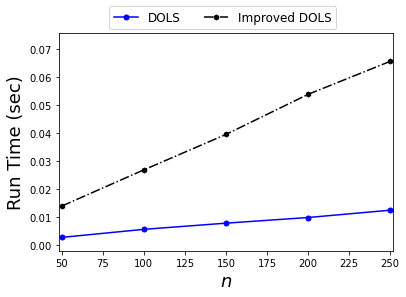

In [5]:
m = 4
n = [50*(i+1) for i in range(5)]

rt = np.zeros((5,2))
for k in range(5):
    for l in range(5):
        x = np.zeros((n[l],m))
        for i in range(m):
            case = random.sample(range(n[l]), k=int(n[l]/2))
            for j in range(int(n[l]/2)):
                r = random.random()
                if r < 1/3:
                    x[case[j]][i] = 0
                elif r < 2/3:
                    x[case[j]][i] = 2
                else:
                    x[case[j]][i] = 4
            for j in range(n[l]):
                if x[j][i] == 1:
                    r = random.random()
                    if r < 1/3:
                        x[j][i] = 1
                    elif r < 2/3:
                        x[j][i] = 3
                    else:
                        x[j][i] = 5
        s = time.time()
        DOLS_chi2(x,n[l],m)
        e = time.time()
        rt[l][0] += e-s
        s = time.time()
        EDOLS_chi2(x,n[l],m)
        e = time.time()
        rt[l][1] += e-s
rt /= 5

print(rt)

fig = plt.figure()
plt.ylim(-0.002, max(rt[i][j] for i in range(5) for j in range(2))+0.01)
plt.xlim(48, 252)
plt.plot(n, rt[:,0], marker="o", markersize=5, color = "blue", linestyle = "-", label = "DOLS")
plt.plot(n, rt[:,1], marker="h", markersize=5, color = "black", linestyle = "dashdot", label = "Improved DOLS")
plt.xlabel("$n$", fontsize = 18)
plt.ylabel("Run Time (sec)", fontsize = 18)
plt.legend(bbox_to_anchor=(0.49, 1.02), loc='lower center', borderaxespad=0, ncol=4, fontsize=12)
fig.savefig("RunTime_mFixed_chi2.png")
fig.savefig("figs/RunTime_mFixed_chi2.eps", bbox_inches="tight", pad_inches=0.05)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


[[0.0020041  0.00852299]
 [0.00395808 0.01787863]
 [0.0078567  0.03876486]
 [0.01485219 0.0892808 ]
 [0.0288888  0.22331667]]


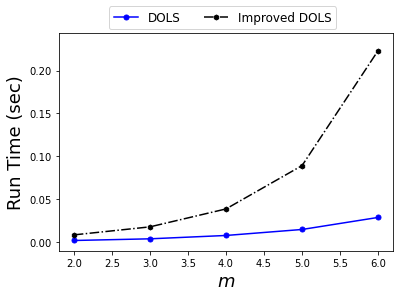

In [6]:
n = 150
m = [2,3,4,5,6]

rt = np.zeros((5,2))
for k in range(5):
    for l in range(5):
        x = np.zeros((n,m[l]))
        for i in range(m[l]):
            case = random.sample(range(n), k=int(n/2))
            for j in range(int(n/2)):
                r = random.random()
                if r < 1/3:
                    x[case[j]][i] = 0
                elif r < 2/3:
                    x[case[j]][i] = 2
                else:
                    x[case[j]][i] = 4
            for j in range(n):
                if x[j][i] == 1:
                    r = random.random()
                    if r < 1/3:
                        x[j][i] = 1
                    elif r < 2/3:
                        x[j][i] = 3
                    else:
                        x[j][i] = 5
        s = time.time()
        DOLS_chi2(x,n,m[l])
        e = time.time()
        rt[l][0] += e-s
        s = time.time()
        EDOLS_chi2(x,n,m[l])
        e = time.time()
        rt[l][1] += e-s
rt /= 5

print(rt)

fig = plt.figure()
plt.ylim(-0.01, max(rt[i][j] for i in range(5) for j in range(2))+0.02)
plt.xlim(1.8,6.2)
plt.plot(m, rt[:,0], marker="o", markersize=5, color = "blue", linestyle = "-", label = "DOLS")
plt.plot(m, rt[:,1], marker="h", markersize=5, color = "black", linestyle = "dashdot", label = "Improved DOLS")
plt.xlabel("$m$", fontsize = 18)
plt.ylabel("Run Time (sec)", fontsize = 18)
plt.legend(bbox_to_anchor=(0.49, 1.02), loc='lower center', borderaxespad=0, ncol=4, fontsize=12)
fig.savefig("RunTime_nFixed_chi2.png")
fig.savefig("figs/RunTime_nFixed_chi2.eps", bbox_inches="tight", pad_inches=0.05)